# پروژه پیش‌بینی شاخص بورس ایران
## Notebook 02 — مدل SARIMAX (اقتصادسنجی)

| موضوع | جزئیات |
|-------|---------|
| متغیر هدف | `log_stock_price` |
| متغیرهای برونزا | تفاضل لگاریتمی: d_oil, d_gold, d_exchange, d_liquidity, d_cpi + cycle_norm |
| انتخاب مرتبه | Grid search روی AIC |
| ارزیابی اصلی | Rolling 1-step-ahead |
| نمودارها | ۱۲ نمودار از ۹ نوع |

> **پیش‌نیاز:** ابتدا `00_data_preparation.ipynb` را اجرا کنید.

## ۱. بارگذاری کتابخانه‌ها

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from itertools import product

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools  import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal   import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import gaussian_kde, probplot

import arabic_reshaper
from bidi.algorithm import get_display

sys.path.append("..")
from src.utils import load_data, get_train_test

def fp(text):
    return get_display(arabic_reshaper.reshape(str(text)))

plt.rcParams["figure.dpi"]  = 120
plt.rcParams["grid.alpha"]  = 0.3
plt.rcParams["font.family"] = "DejaVu Sans"
os.makedirs("../results/figures", exist_ok=True)
print("✓ کتابخانه‌ها آماده‌اند")

✓ کتابخانه‌ها آماده‌اند


## ۲. بارگذاری داده و مهندسی ویژگی

متغیرهای اقتصادی ایران (نرخ ارز، نقدینگی، تورم) روند شدید صعودی دارند.
اگر در سطح وارد SARIMAX شوند، پیش‌بینی در horizon بلند منفجر می‌شود.
**راه‌حل:** تبدیل به تغییرات لگاریتمی (`Δlog`) که پایا (I(0)) هستند.

In [2]:
df = load_data()
train, test = get_train_test(df, test_quarters=16)

# ── ساخت متغیرهای تفاضلی لگاریتمی (پایا)
for col in ["oil", "gold", "export", "import", "exchange", "liquidity", "cpi"]:
    df[f"d_{col}"] = np.log(df[col]).diff()

# صفر-محور کردن cycle: 1→-1, 2→0, 3→+1
df["cycle_norm"] = df["cycle"] - 2.0

# ── ستون‌های مدل (همه باید پایا باشند)
EXOG_D     = ["d_oil","d_gold","d_export","d_import",
              "d_exchange","d_liquidity","d_cpi","cycle_norm"]
TARGET_COL = "log_stock_price"

# حذف NaN ناشی از diff
df_clean = df.dropna(subset=EXOG_D + [TARGET_COL]).copy()
train_c  = df_clean.loc[df_clean.index.isin(train.index)]
test_c   = df_clean.loc[df_clean.index.isin(test.index)]

y_train      = train_c[TARGET_COL]
y_test       = test_c[TARGET_COL]
X_train      = train_c[EXOG_D]
X_test       = test_c[EXOG_D]
y_true_price = test_c["stock_price"].values
test_dates   = test_c.index.to_timestamp()

print(f"✓ آموزش  : {len(y_train)} مشاهده  [{y_train.index[0]} → {y_train.index[-1]}]")
print(f"✓ آزمون  : {len(y_test)}  مشاهده  [{y_test.index[0]} → {y_test.index[-1]}]")
print(f"✓ متغیرهای مدل: {EXOG_D}")

✓ آموزش  : 74 مشاهده  [2000Q3 → 2018Q4]
✓ آزمون  : 16  مشاهده  [2019Q1 → 2022Q4]
✓ متغیرهای مدل: ['d_oil', 'd_gold', 'd_export', 'd_import', 'd_exchange', 'd_liquidity', 'd_cpi', 'cycle_norm']


## ۳. تجزیه STL سری زمانی

قبل از مدل‌سازی، سری زمانی را به اجزای **روند، فصلی و پسماند** تجزیه می‌کنیم.

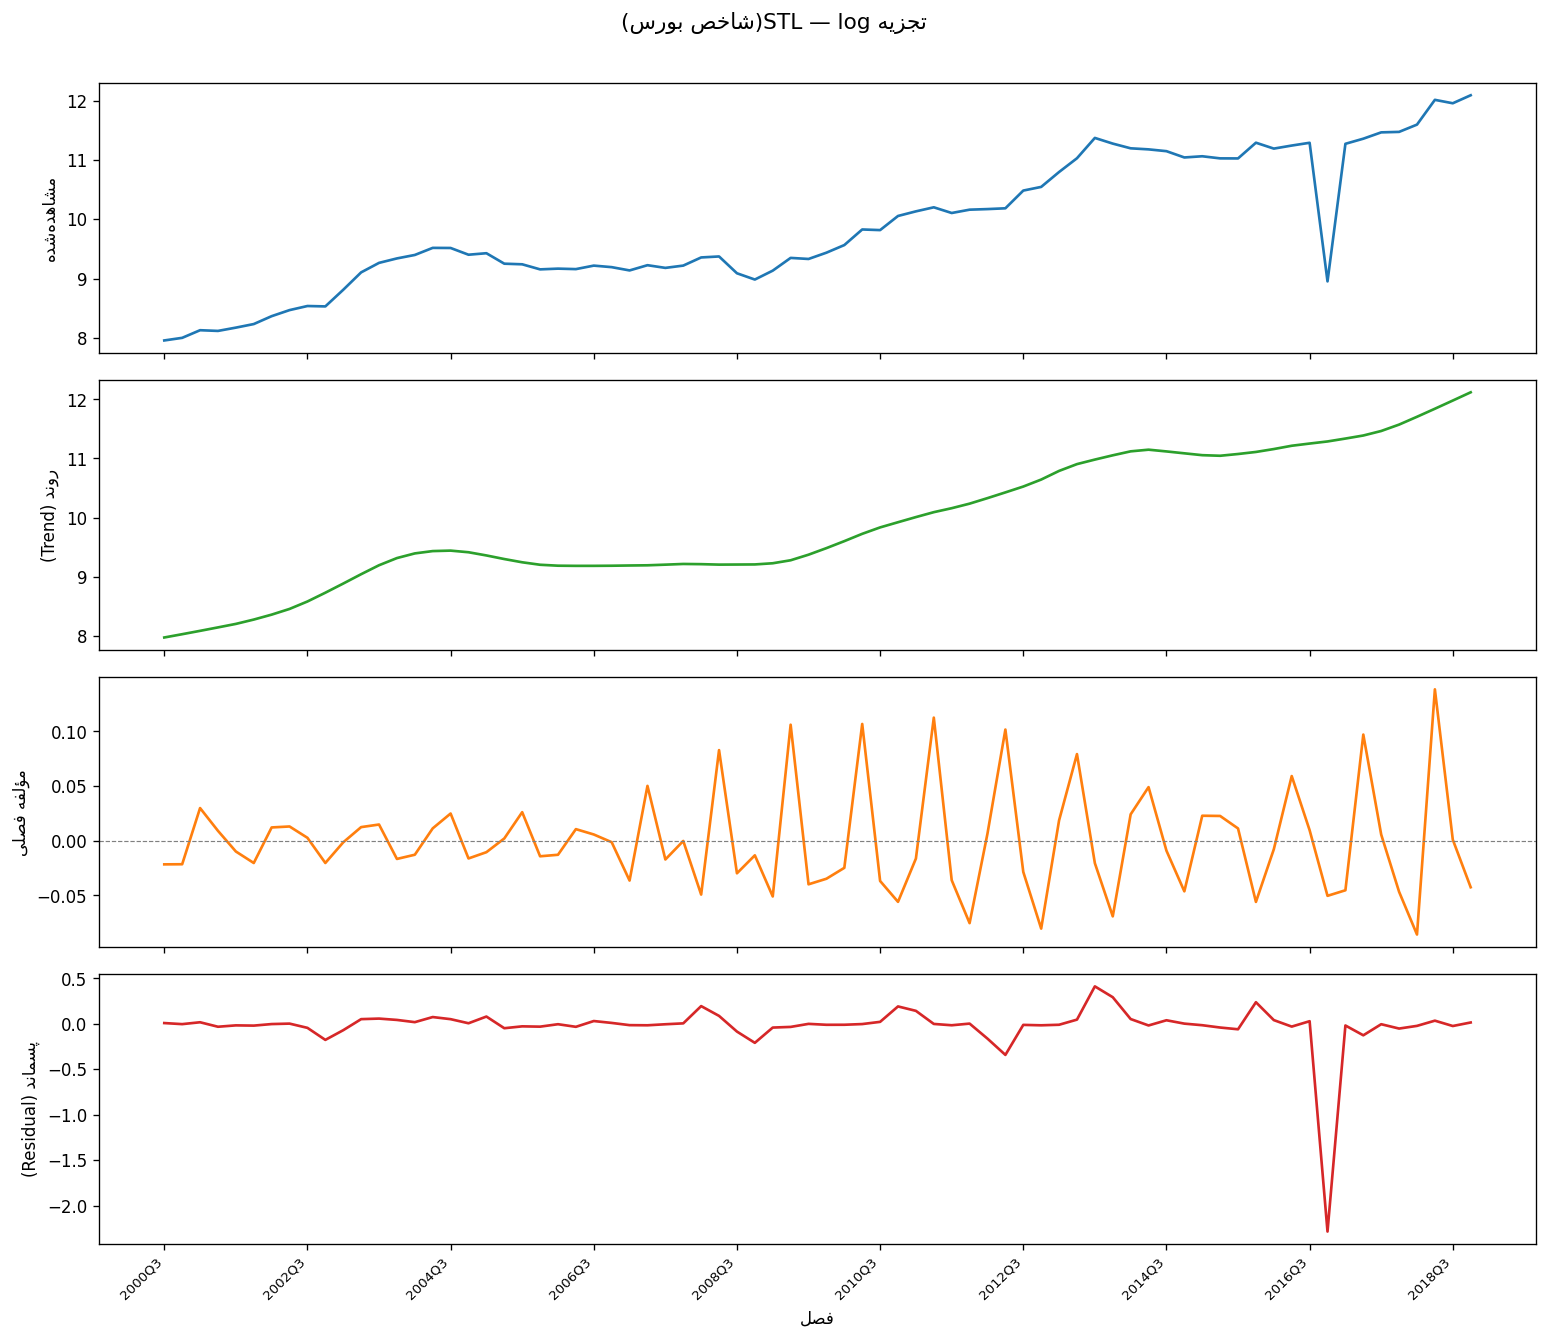

✓ نمودار ۱ ذخیره شد | قدرت روند: 0.935 | قدرت فصلی: 0.036


In [3]:
# نمودار ۱ — تجزیه STL
stl     = STL(y_train, period=4, robust=True)
stl_res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
labels = [fp("مشاهده‌شده"), fp("روند (Trend)"),
          fp("مؤلفه فصلی"), fp("پسماند (Residual)")]
series = [y_train.values, stl_res.trend, stl_res.seasonal, stl_res.resid]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]
x_idx  = range(len(y_train))

for ax, data, lbl, col in zip(axes, series, labels, colors):
    ax.plot(x_idx, data, color=col, linewidth=1.6)
    ax.set_ylabel(lbl, fontsize=10)
    if lbl == labels[2]:
        ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")

axes[-1].set_xticks(range(0, len(y_train), 8))
axes[-1].set_xticklabels(y_train.index[::8].astype(str), rotation=45, ha="right", fontsize=8)
axes[-1].set_xlabel(fp("فصل"), fontsize=10)
fig.suptitle(fp("تجزیه STL — log(شاخص بورس)"), fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../results/figures/02_stl_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

strength_t = max(0, 1 - np.var(stl_res.resid)/np.var(stl_res.trend   + stl_res.resid))
strength_s = max(0, 1 - np.var(stl_res.resid)/np.var(stl_res.seasonal + stl_res.resid))
print(f"✓ نمودار ۱ ذخیره شد | قدرت روند: {strength_t:.3f} | قدرت فصلی: {strength_s:.3f}")

## ۴. آزمون پایایی (ADF)

**H₀:** سری ناپایاست  →  اگر p-value < 0.05: رد H₀ → سری پایاست

In [4]:
vars_to_test = [TARGET_COL, "log_return",
                "d_oil","d_gold","d_exchange","d_liquidity","d_cpi","cycle_norm"]
adf_results  = []
for var in vars_to_test:
    s = df_clean[var].dropna()
    stat, pval, *_ = adfuller(s, autolag="AIC")
    adf_results.append({"متغیر": var,
                         "ADF": round(stat, 3),
                         "p-value": round(pval, 4),
                         "پایا؟": "✓ بله" if pval < 0.05 else "✗ خیر"})

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))
print(f"📌 متغیرهای d_ تفاضلی همه پایا هستند → مناسب برای exog")

          متغیر     ADF  p-value پایا؟
log_stock_price   0.183   0.9713 ✗ خیر
     log_return -13.524   0.0000 ✓ بله
          d_oil  -8.539   0.0000 ✓ بله
         d_gold  -9.580   0.0000 ✓ بله
     d_exchange  -4.802   0.0001 ✓ بله
    d_liquidity  -3.329   0.0136 ✓ بله
          d_cpi  -1.634   0.4656 ✗ خیر
     cycle_norm  -1.567   0.5000 ✗ خیر
📌 متغیرهای d_ تفاضلی همه پایا هستند → مناسب برای exog


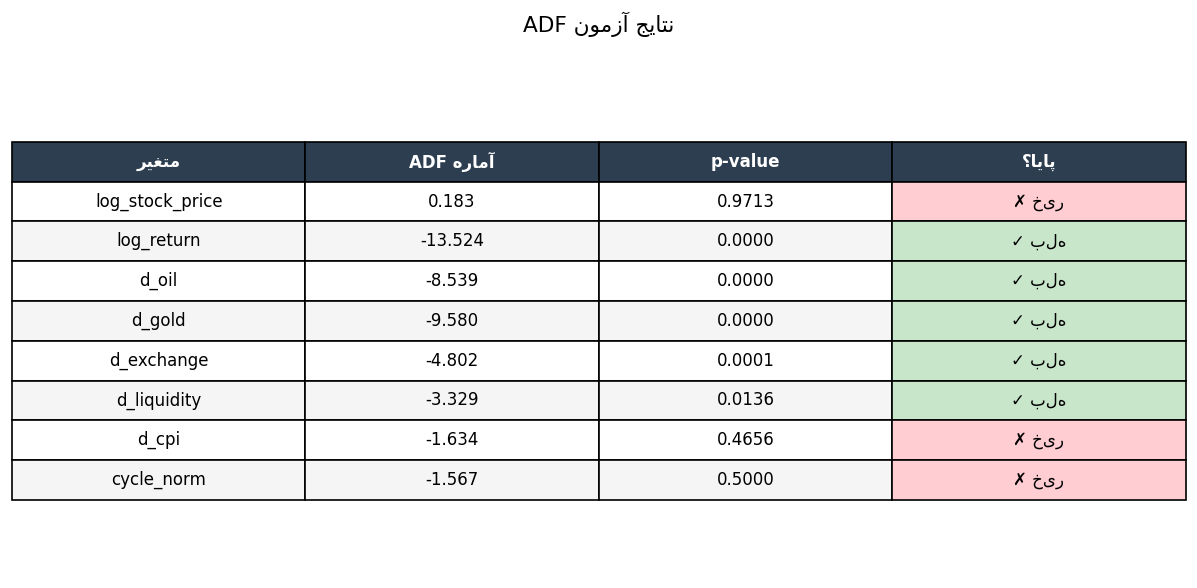

✓ نمودار ۲ ذخیره شد


In [5]:
# نمودار ۲ — جدول رنگی پایایی
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
col_lbl = [fp("متغیر"), fp("ADF آماره"), fp("p-value"), fp("پایا؟")]
row_vals = [[r["متغیر"], f"{r['ADF']:.3f}", f"{r['p-value']:.4f}", r["پایا؟"]]
            for r in adf_results]
tbl = ax.table(cellText=row_vals, colLabels=col_lbl, loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50"); cell.set_text_props(color="white", fontweight="bold")
    elif col == 3 and row > 0:
        cell.set_facecolor("#c8e6c9" if "بله" in row_vals[row-1][3] else "#ffcdd2")
    elif row % 2 == 0:
        cell.set_facecolor("#f5f5f5")
ax.set_title(fp("نتایج آزمون ADF"), fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("../results/figures/02_stationarity_tests.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۲ ذخیره شد")

## ۵. نمودار ACF و PACF

- **PACF** بریده می‌شود در lag `p` → مرتبه AR
- **ACF** بریده می‌شود در lag `q` → مرتبه MA

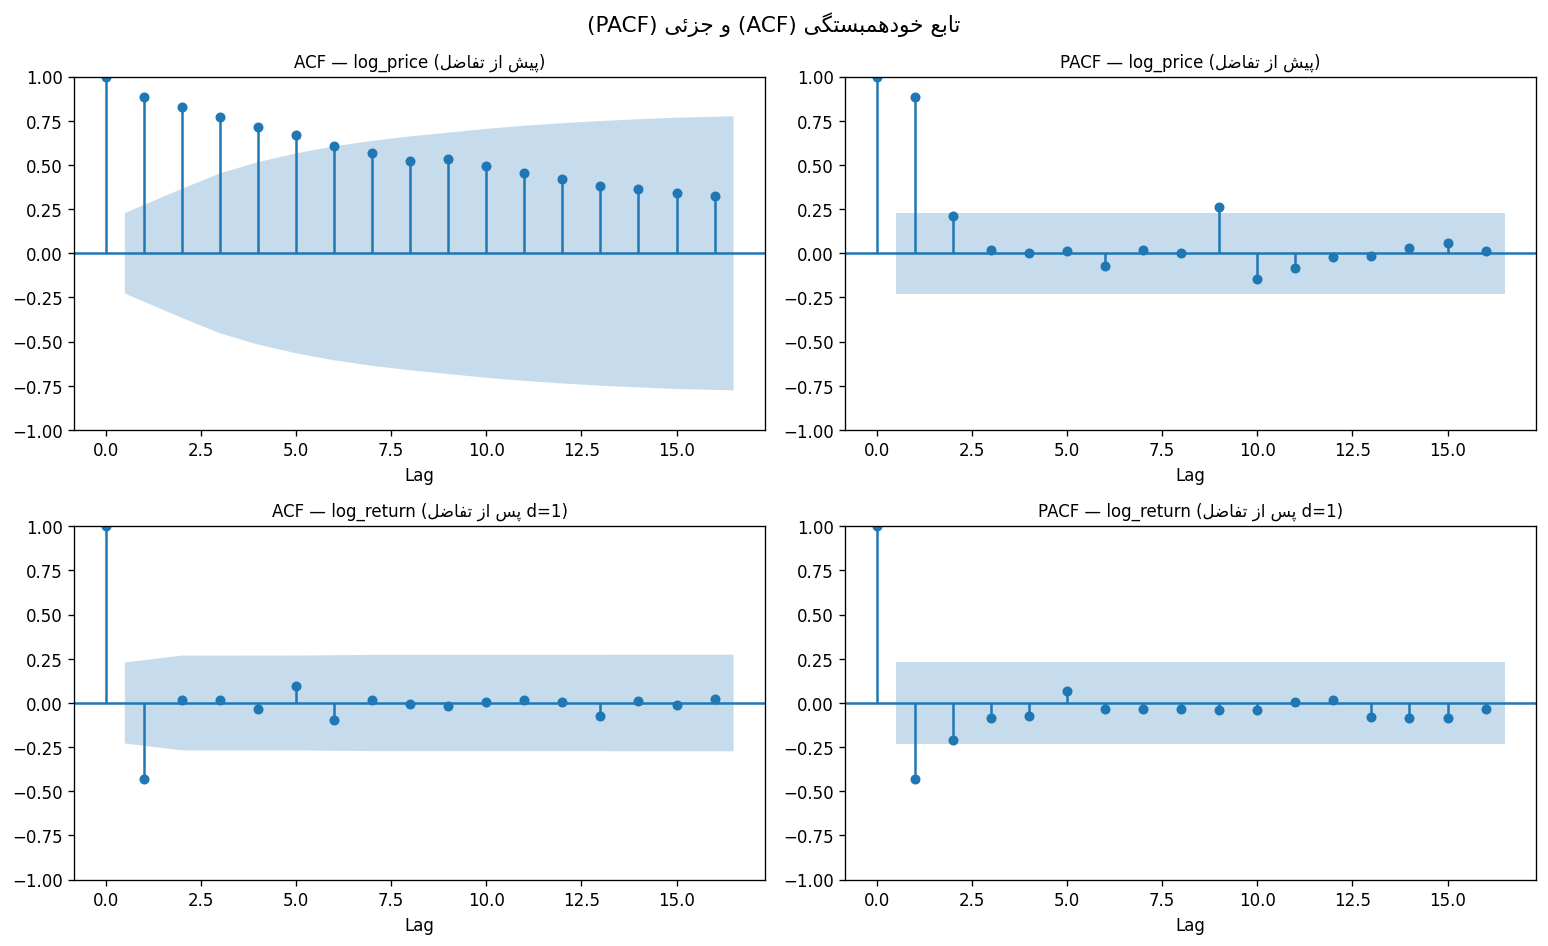

✓ نمودار ۳ ذخیره شد


In [6]:
# نمودار ۳ — ACF/PACF قبل و بعد از تفاضل
log_price = y_train.values
log_ret   = np.diff(log_price)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_acf (log_price, lags=16, ax=axes[0,0], alpha=0.05)
plot_pacf(log_price, lags=16, ax=axes[0,1], alpha=0.05, method="ywm")
plot_acf (log_ret,   lags=16, ax=axes[1,0], alpha=0.05)
plot_pacf(log_ret,   lags=16, ax=axes[1,1], alpha=0.05, method="ywm")

titles = [fp("ACF — log_price (پیش از تفاضل)"),
          fp("PACF — log_price (پیش از تفاضل)"),
          fp("ACF — log_return (پس از تفاضل d=1)"),
          fp("PACF — log_return (پس از تفاضل d=1)")]
for ax, t in zip(axes.flatten(), titles):
    ax.set_title(t, fontsize=10)
    ax.set_xlabel(fp("Lag"))

plt.suptitle(fp("تابع خودهمبستگی (ACF) و جزئی (PACF)"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/02_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۳ ذخیره شد")

## ۶. آنالیز VIF — بررسی همخطی

**VIF > 10** → همخطی شدید | **VIF > 5** → هشدار

این نمودار توجیه استفاده از PCA در مدل هیبرید (notebook 04) را نشان می‌دهد.

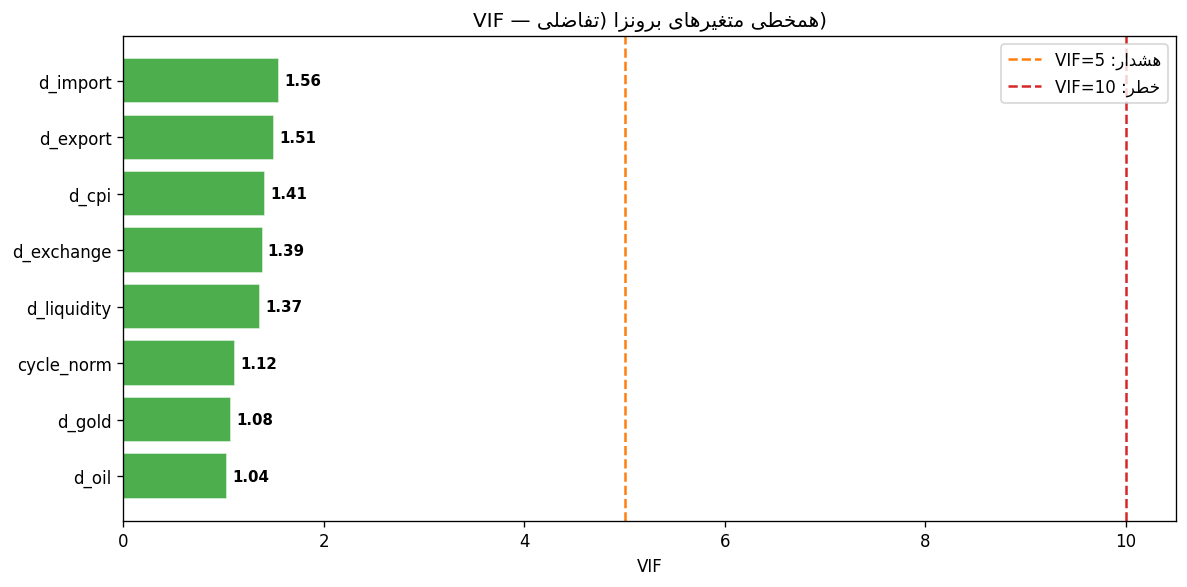

✓ نمودار ۴ ذخیره شد


In [7]:
# نمودار ۴ — VIF متغیرهای تفاضلی
X_vif    = add_constant(X_train.values)
vif_vals = [variance_inflation_factor(X_vif, i+1) for i in range(len(EXOG_D))]
vif_df   = pd.DataFrame({"feature": EXOG_D, "VIF": vif_vals}).sort_values("VIF")

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#2ca02c" if v < 5 else ("#ff7f0e" if v < 10 else "#d62728")
              for v in vif_df["VIF"]]
bars = ax.barh(vif_df["feature"], vif_df["VIF"],
               color=bar_colors, alpha=0.85, edgecolor="white")
ax.axvline(5,  color="#ff7f0e", lw=1.5, linestyle="--", label=fp("هشدار: VIF=5"))
ax.axvline(10, color="#d62728", lw=1.5, linestyle="--", label=fp("خطر: VIF=10"))
for bar, val in zip(bars, vif_df["VIF"]):
    ax.text(val + 0.05, bar.get_y()+bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9, fontweight="bold")
ax.set_title(fp("VIF — همخطی متغیرهای برونزا (تفاضلی)"), fontsize=12)
ax.set_xlabel("VIF"); ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/02_vif_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۴ ذخیره شد")

## ۷. انتخاب مرتبه بهینه با معیار AIC

جستجو روی SARIMAX(p,1,q)(0,0,0)[4] برای p,q ∈ {0,1,2,3}

In [8]:
print("در حال جستجوی مرتبه بهینه...")
aic_grid = {}; bic_grid = {}
best_aic = np.inf; best_order = (1,1,1); best_res = None

for p, q in product(range(4), range(4)):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mod = SARIMAX(y_train, exog=X_train,
                          order=(p,1,q), seasonal_order=(0,0,0,4),
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False, maxiter=200, method="powell")
            aic_grid[(p,q)] = res.aic; bic_grid[(p,q)] = res.bic
            if res.aic < best_aic:
                best_aic = res.aic; best_order = (p,1,q); best_res = res
            print(f"  SARIMAX({p},1,{q}) — AIC={res.aic:.2f}  BIC={res.bic:.2f}")
    except:
        aic_grid[(p,q)] = np.nan; bic_grid[(p,q)] = np.nan

print(f"✓ بهترین: SARIMAX{best_order}  AIC={best_aic:.2f}")

در حال جستجوی مرتبه بهینه...
  SARIMAX(0,1,0) — AIC=83.43  BIC=103.92
  SARIMAX(0,1,1) — AIC=76.11  BIC=98.74
  SARIMAX(0,1,2) — AIC=76.90  BIC=101.64
  SARIMAX(0,1,3) — AIC=78.05  BIC=104.86
  SARIMAX(1,1,0) — AIC=76.61  BIC=99.38
  SARIMAX(1,1,1) — AIC=77.50  BIC=102.39
  SARIMAX(1,1,2) — AIC=79.77  BIC=106.75
  SARIMAX(1,1,3) — AIC=79.86  BIC=108.90
  SARIMAX(2,1,0) — AIC=76.76  BIC=101.64
  SARIMAX(2,1,1) — AIC=78.48  BIC=105.63
  SARIMAX(2,1,2) — AIC=80.53  BIC=109.76
  SARIMAX(2,1,3) — AIC=81.90  BIC=113.18
  SARIMAX(3,1,0) — AIC=78.42  BIC=105.40
  SARIMAX(3,1,1) — AIC=80.33  BIC=109.56
  SARIMAX(3,1,2) — AIC=82.11  BIC=113.59
  SARIMAX(3,1,3) — AIC=83.79  BIC=117.31
✓ بهترین: SARIMAX(0, 1, 1)  AIC=76.11


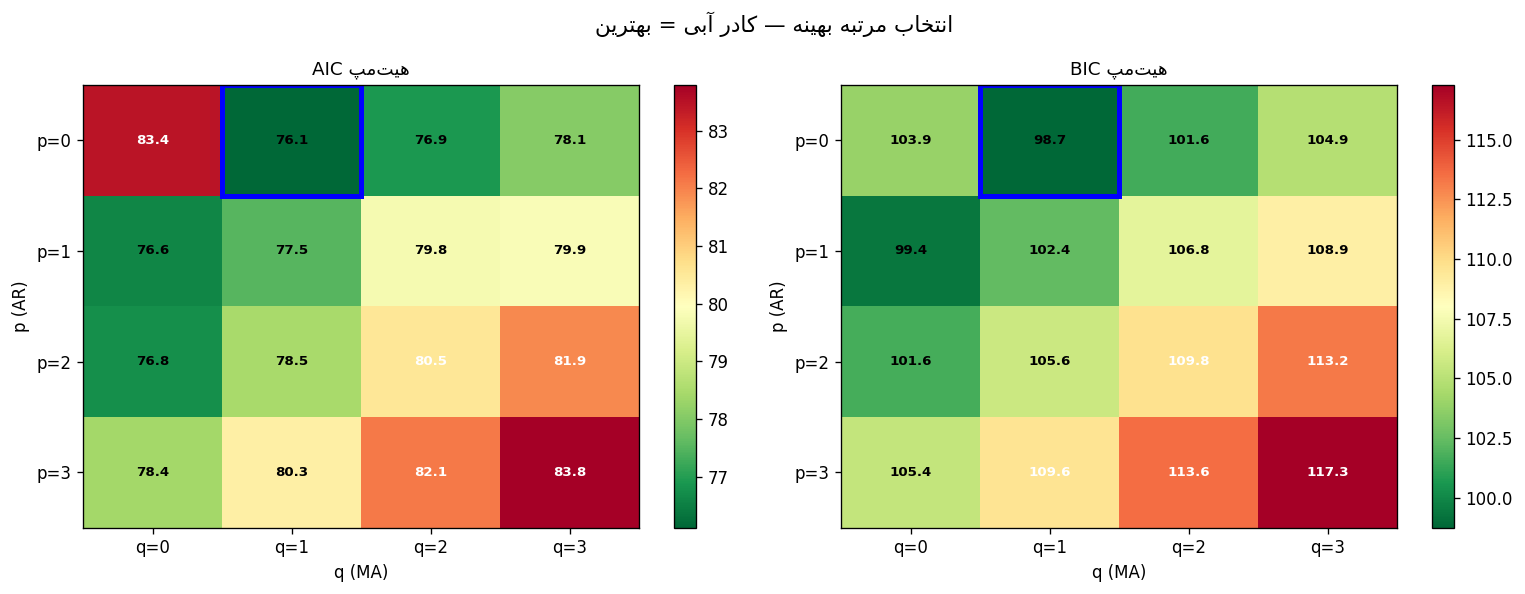

✓ نمودار ۵ ذخیره شد  |  p=0, q=1


In [9]:
# نمودار ۵ — هیت‌مپ AIC/BIC
ps = sorted(set(k[0] for k in aic_grid))
qs = sorted(set(k[1] for k in aic_grid))
aic_mat = np.array([[aic_grid.get((p,q),np.nan) for q in qs] for p in ps])
bic_mat = np.array([[bic_grid.get((p,q),np.nan) for q in qs] for p in ps])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in zip(axes,
        [aic_mat, bic_mat],
        [fp("هیت‌مپ AIC"), fp("هیت‌مپ BIC")]):
    masked = np.ma.masked_invalid(mat)
    im = ax.imshow(masked, cmap="RdYlGn_r", aspect="auto")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(qs))); ax.set_xticklabels([f"q={q}" for q in qs])
    ax.set_yticks(range(len(ps))); ax.set_yticklabels([f"p={p}" for p in ps])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("q (MA)"); ax.set_ylabel("p (AR)")
    for i in range(len(ps)):
        for j in range(len(qs)):
            if not np.isnan(mat[i,j]):
                clr = "white" if mat[i,j] > np.nanpercentile(mat,70) else "black"
                ax.text(j, i, f"{mat[i,j]:.1f}", ha="center", va="center",
                        fontsize=8, color=clr, fontweight="bold")
    bp, bq = best_order[0], best_order[2]
    ax.add_patch(plt.Rectangle((qs.index(bq)-.5, ps.index(bp)-.5), 1, 1,
                                 fill=False, edgecolor="blue", lw=3))

plt.suptitle(fp("انتخاب مرتبه بهینه — کادر آبی = بهترین"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/02_aic_bic_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ نمودار ۵ ذخیره شد  |  p={best_order[0]}, q={best_order[2]}")

## ۸. برازش مدل نهایی

In [10]:
fitted = best_res
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:        log_stock_price   No. Observations:                   74
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 -28.057
Date:                Fri, 29 May 2026   AIC                             76.114
Time:                        09:41:04   BIC                             98.740
Sample:                    09-30-2000   HQIC                            85.112
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
d_oil          -0.0840      0.702     -0.120      0.905      -1.461       1.293
d_gold          1.2616      0.942      1.340      0.180      -0.584       3.107
d_export        0.1206      0.535      0.225    

## ۹. تفسیر ضرایب
ضریبی که بازه اطمینانش از صفر عبور نمی‌کند **معنی‌دار آماری** است.

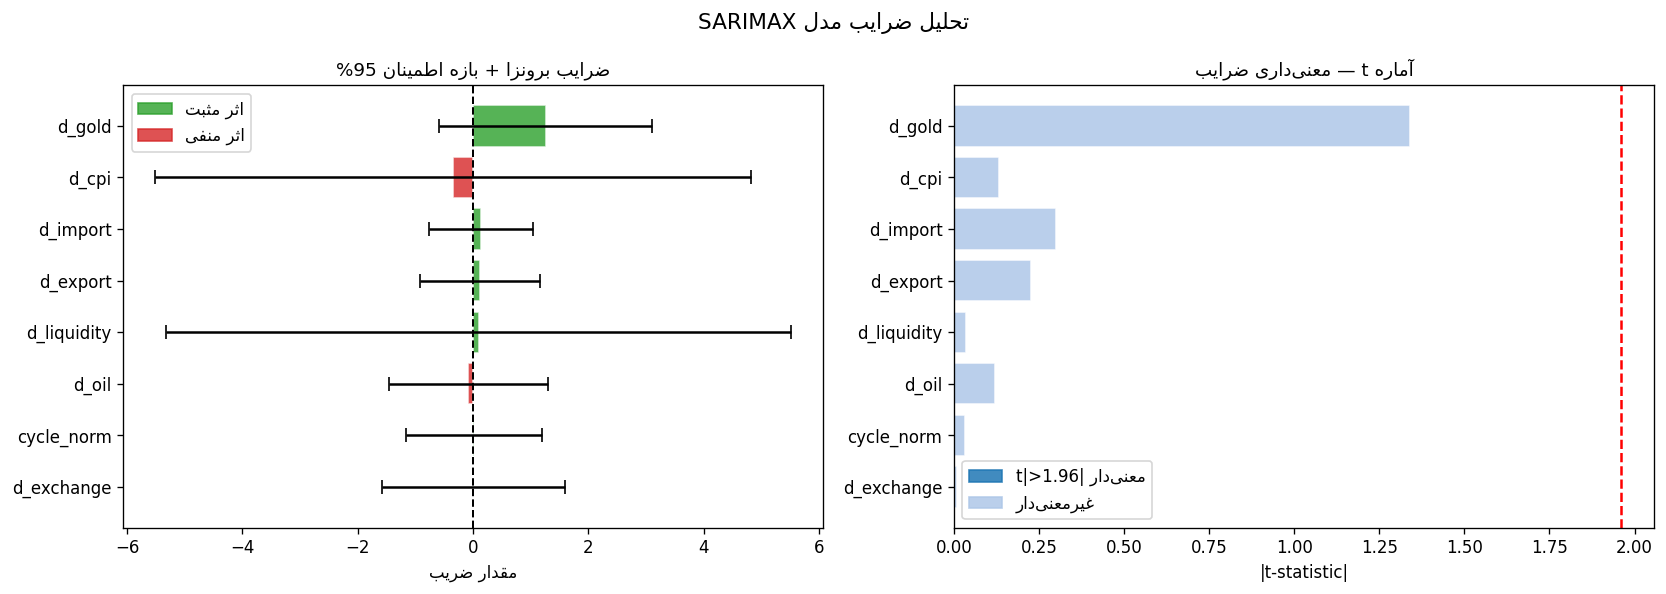

✓ نمودار ۶ ذخیره شد


In [11]:
# نمودار ۶ — ضرایب + t-statistics
params   = fitted.params; conf = fitted.conf_int()
pnames   = list(params.index)
exog_idx = [n in EXOG_D for n in pnames]
ex_names = [n for n,m in zip(pnames,exog_idx) if m]
ex_coefs = params[exog_idx].values
ex_lo    = conf.iloc[:,0][exog_idx].values
ex_hi    = conf.iloc[:,1][exog_idx].values
ex_se    = (ex_hi - ex_lo) / (2*1.96)
t_stats  = fitted.tvalues[exog_idx].values
sidx     = np.argsort(np.abs(ex_coefs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ضرایب با CI
colors_c = ["#2ca02c" if c>0 else "#d62728" for c in ex_coefs[sidx]]
axes[0].barh(range(len(ex_names)), ex_coefs[sidx], xerr=ex_se[sidx]*1.96,
             color=colors_c, alpha=0.8, edgecolor="white", capsize=4)
axes[0].set_yticks(range(len(ex_names)))
axes[0].set_yticklabels(np.array(ex_names)[sidx], fontsize=10)
axes[0].axvline(0, color="black", lw=1.2, linestyle="--")
axes[0].set_title(fp("ضرایب برونزا + بازه اطمینان 95%"), fontsize=11)
axes[0].set_xlabel(fp("مقدار ضریب"))
axes[0].legend(handles=[mpatches.Patch(color="#2ca02c",alpha=0.8,label=fp("اثر مثبت")),
                          mpatches.Patch(color="#d62728",alpha=0.8,label=fp("اثر منفی"))])

# t-statistics
sig     = np.abs(t_stats) > 1.96
bar_c2  = ["#1f77b4" if s else "#aec7e8" for s in sig[sidx]]
axes[1].barh(range(len(ex_names)), np.abs(t_stats[sidx]),
             color=bar_c2, alpha=0.85, edgecolor="white")
axes[1].axvline(1.96, color="red", lw=1.5, linestyle="--",
                label=fp("آستانه: |t| = 1.96"))
axes[1].set_yticks(range(len(ex_names)))
axes[1].set_yticklabels(np.array(ex_names)[sidx], fontsize=10)
axes[1].set_title(fp("آماره t — معنی‌داری ضرایب"), fontsize=11)
axes[1].set_xlabel(fp("|t-statistic|"))
axes[1].legend(handles=[mpatches.Patch(color="#1f77b4",alpha=0.85,label=fp("معنی‌دار |t|>1.96")),
                          mpatches.Patch(color="#aec7e8",alpha=0.85,label=fp("غیرمعنی‌دار"))])

plt.suptitle(fp("تحلیل ضرایب مدل SARIMAX"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/02_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۶ ذخیره شد")

## ۱۰. تشخیص پسماند

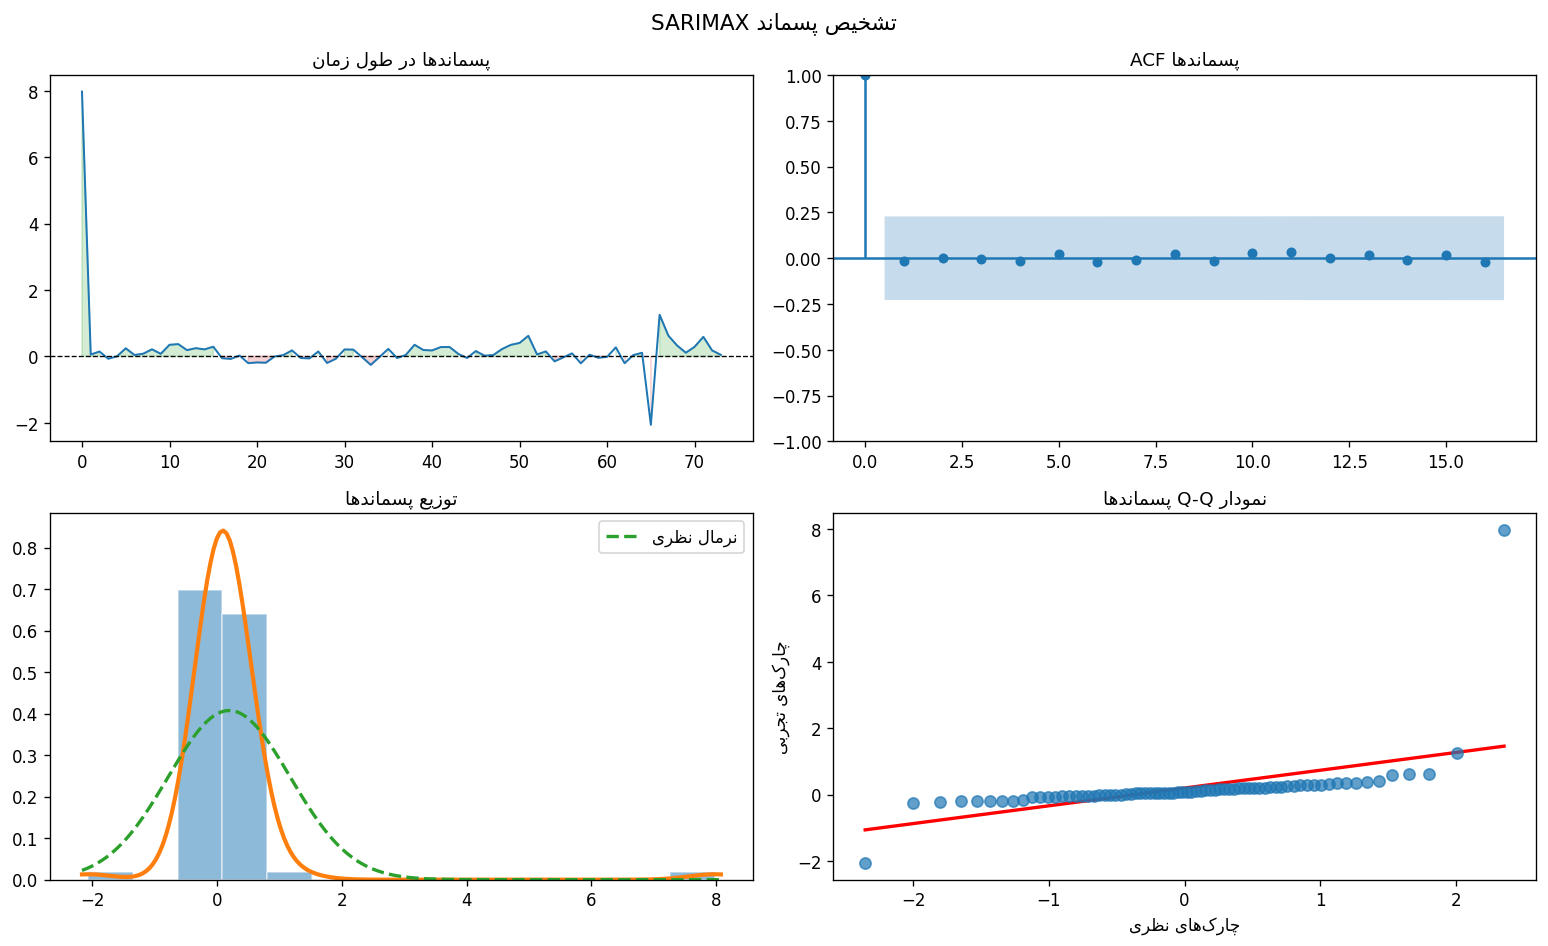

✓ نمودار ۷ ذخیره شد
  آزمون Ljung-Box:
    lag= 4: p=0.9998  ✓ OK (no autocorrelation)
    lag= 8: p=1.0000  ✓ OK (no autocorrelation)
    lag=12: p=1.0000  ✓ OK (no autocorrelation)


In [12]:
# نمودار ۷ — 4-panel تشخیص پسماند
resid  = fitted.resid.dropna()
lb_res = acorr_ljungbox(resid, lags=[4,8,12], return_df=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(range(len(resid)), resid.values, color="#1f77b4", lw=1.2)
axes[0,0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0,0].fill_between(range(len(resid)), resid.values, 0,
    where=resid.values>0, alpha=0.2, color="#2ca02c")
axes[0,0].fill_between(range(len(resid)), resid.values, 0,
    where=resid.values<0, alpha=0.2, color="#d62728")
axes[0,0].set_title(fp("پسماندها در طول زمان"), fontsize=11)

plot_acf(resid, lags=16, ax=axes[0,1], alpha=0.05)
axes[0,1].set_title(fp("ACF پسماندها"), fontsize=11)

from scipy.stats import norm
x_k = np.linspace(resid.min()-.1, resid.max()+.1, 200)
axes[1,0].hist(resid.values, bins=14, color="#1f77b4", alpha=0.5,
               edgecolor="white", density=True)
axes[1,0].plot(x_k, gaussian_kde(resid.values)(x_k), color="#ff7f0e", lw=2.5)
axes[1,0].plot(x_k, norm.pdf(x_k, resid.mean(), resid.std()),
               color="#2ca02c", lw=2, linestyle="--", label=fp("نرمال نظری"))
axes[1,0].set_title(fp("توزیع پسماندها"), fontsize=11); axes[1,0].legend()

(osm, osr), (slope, intercept, _) = probplot(resid.values, dist="norm")
axes[1,1].scatter(osm, osr, color="#1f77b4", alpha=0.7, s=45, zorder=3)
xl = np.array([min(osm), max(osm)])
axes[1,1].plot(xl, slope*xl+intercept, color="red", lw=2)
axes[1,1].set_title(fp("نمودار Q-Q پسماندها"), fontsize=11)
axes[1,1].set_xlabel(fp("چارک‌های نظری")); axes[1,1].set_ylabel(fp("چارک‌های تجربی"))

plt.suptitle(fp("تشخیص پسماند SARIMAX"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/02_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ نمودار ۷ ذخیره شد")
print("  آزمون Ljung-Box:")
for _, row in lb_res.iterrows():
    sig = "✓ OK (no autocorrelation)" if row["lb_pvalue"] > 0.05 else "✗ همبستگی سریالی"
    print(f"    lag={int(row.name):2d}: p={row['lb_pvalue']:.4f}  {sig}")

## ۱۱. برازش درون‌نمونه‌ای

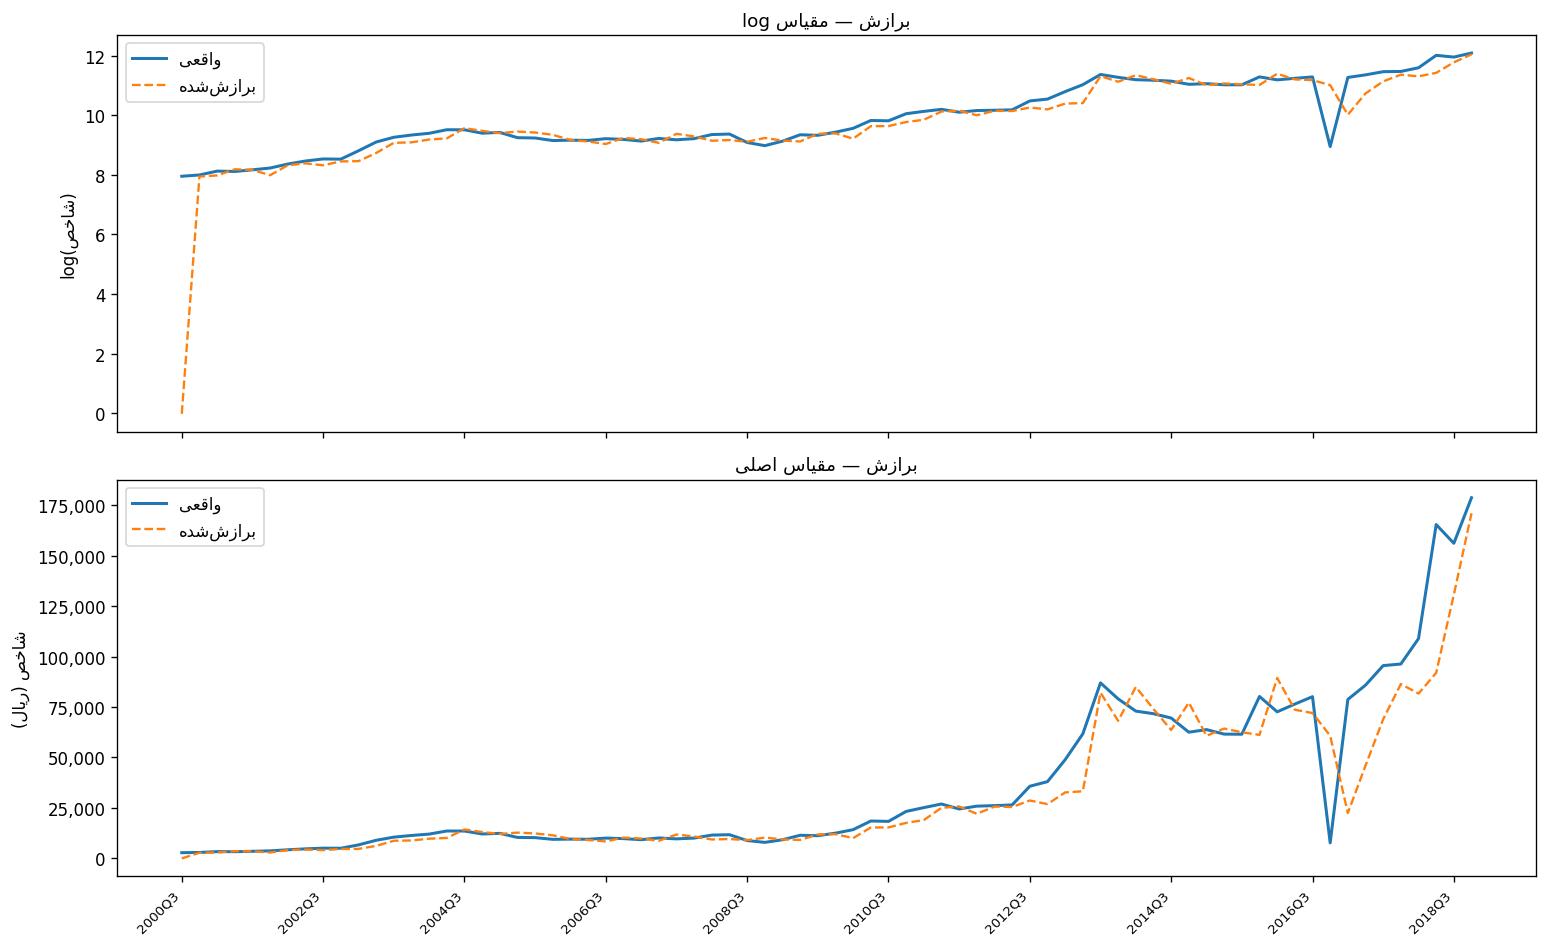

✓ نمودار ۸ ذخیره شد


In [13]:
# نمودار ۸ — in-sample fit
insample_pred  = fitted.fittedvalues
insample_price = np.exp(insample_pred.values)
actual_price   = np.exp(y_train.values)
x_tr = range(len(y_train))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(x_tr, y_train.values, color="#1f77b4", lw=1.8, label=fp("واقعی"))
axes[0].plot(x_tr, insample_pred.values, color="#ff7f0e", lw=1.4,
             linestyle="--", label=fp("برازش‌شده"))
axes[0].set_ylabel(fp("log(شاخص)")); axes[0].set_title(fp("برازش — مقیاس log"), fontsize=11)
axes[0].legend()

axes[1].plot(x_tr, actual_price, color="#1f77b4", lw=1.8, label=fp("واقعی"))
axes[1].plot(x_tr, insample_price, color="#ff7f0e", lw=1.4,
             linestyle="--", label=fp("برازش‌شده"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
axes[1].set_ylabel(fp("شاخص (ریال)")); axes[1].set_title(fp("برازش — مقیاس اصلی"), fontsize=11)
axes[1].set_xticks(range(0,len(y_train),8))
axes[1].set_xticklabels(y_train.index[::8].astype(str), rotation=45, ha="right", fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/figures/02_insample_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۸ ذخیره شد")

## ۱۲. پیش‌بینی برون‌نمونه با بازه اطمینان ۹۵٪

مزیت کلیدی SARIMAX: نمایش عدم قطعیت پیش‌بینی

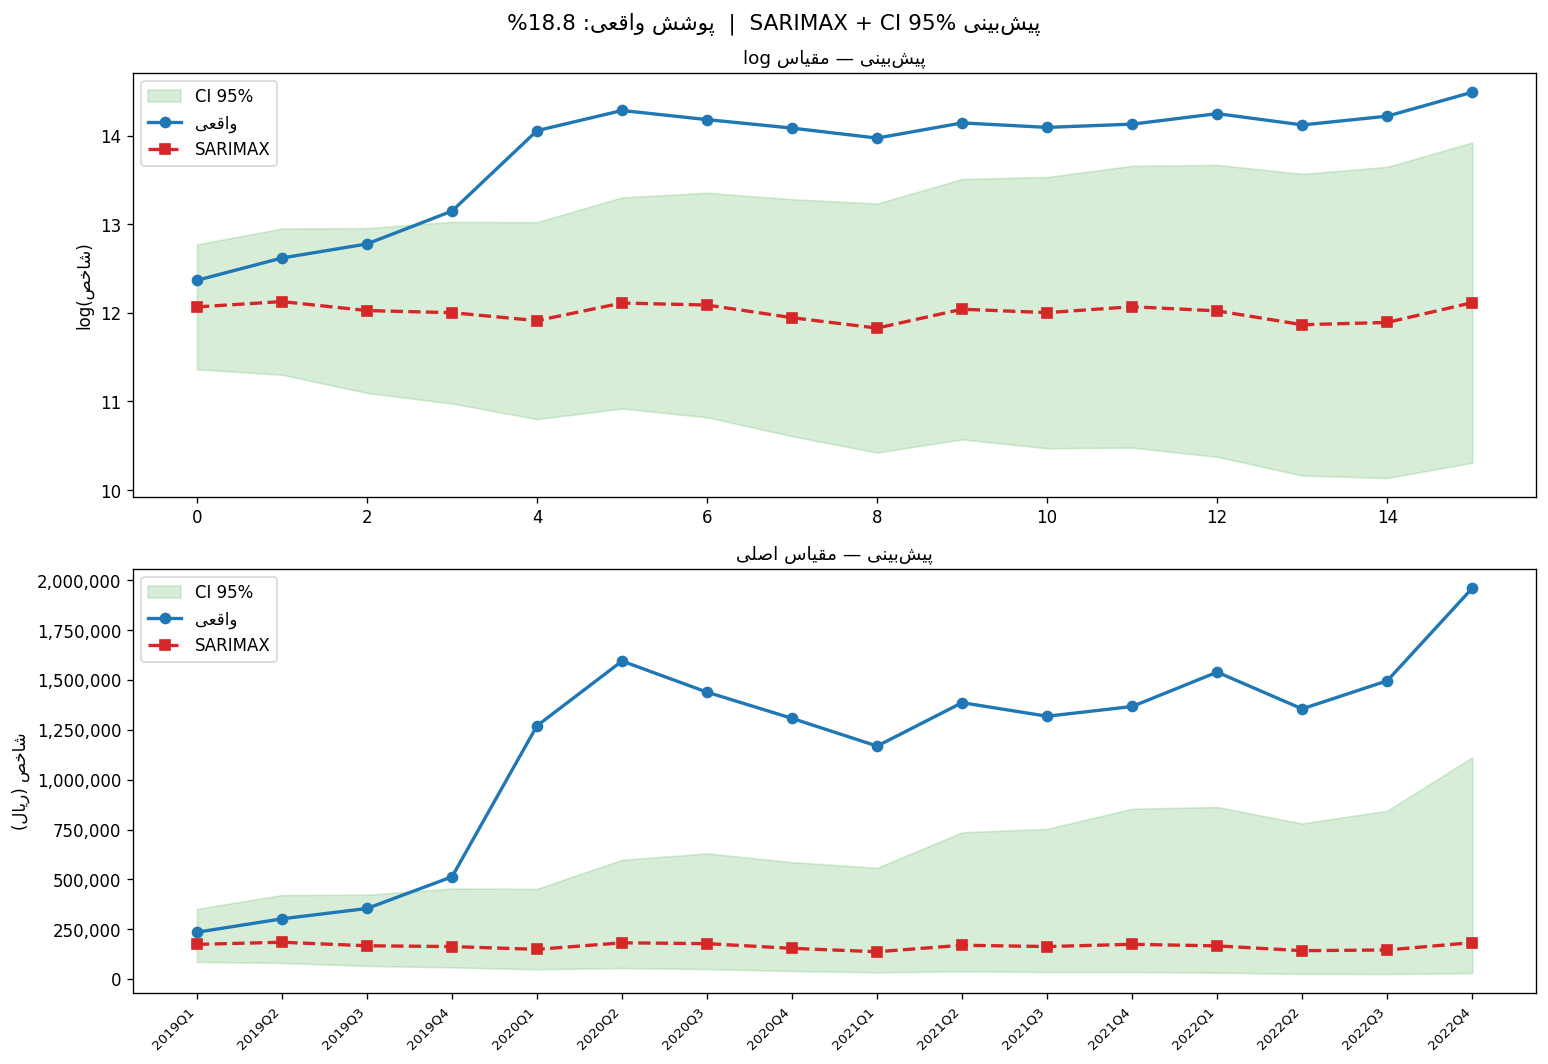

✓ نمودار ۹ ذخیره شد  |  پوشش CI: 18.8%


In [14]:
forecast_res = fitted.get_forecast(steps=len(y_test), exog=X_test)
fc_mean      = forecast_res.predicted_mean
fc_ci        = forecast_res.conf_int(alpha=0.05)

y_pred_log   = fc_mean.values
y_pred_price = np.exp(y_pred_log)
ci_lower     = np.exp(fc_ci.iloc[:,0].values)
ci_upper     = np.exp(fc_ci.iloc[:,1].values)
x_t          = range(len(y_test))

# نمودار ۹ — پیش‌بینی با CI
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax_i, (ytrue, ypred, ylower, yupper, ylabel, title) in enumerate([
    (y_test.values, y_pred_log,
     fc_ci.iloc[:,0].values, fc_ci.iloc[:,1].values,
     fp("log(شاخص)"), fp("پیش‌بینی — مقیاس log")),
    (y_true_price, y_pred_price, ci_lower, ci_upper,
     fp("شاخص (ریال)"), fp("پیش‌بینی — مقیاس اصلی"))
]):
    axes[ax_i].fill_between(x_t, ylower, yupper,
                             alpha=0.18, color="#2ca02c", label=fp("CI 95%"))
    axes[ax_i].plot(x_t, ytrue, color="#1f77b4", marker="o", ms=6,
                    lw=2, label=fp("واقعی"), zorder=4)
    axes[ax_i].plot(x_t, ypred, color="#d62728", marker="s", ms=6,
                    lw=2, linestyle="--", label=fp("SARIMAX"), zorder=4)
    axes[ax_i].set_ylabel(ylabel); axes[ax_i].set_title(title, fontsize=11)
    axes[ax_i].legend()
    if ax_i == 1:
        axes[ax_i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
        axes[ax_i].set_xticks(x_t)
        axes[ax_i].set_xticklabels(y_test.index.astype(str),
                                    rotation=45, ha="right", fontsize=8)

coverage = np.mean((y_true_price>=ci_lower) & (y_true_price<=ci_upper)) * 100
plt.suptitle(fp(f"پیش‌بینی SARIMAX + CI 95%  |  پوشش واقعی: {coverage:.1f}%"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/02_forecast_with_ci.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ نمودار ۹ ذخیره شد  |  پوشش CI: {coverage:.1f}%")

## ۱۳. پیش‌بینی Rolling 1-Step-Ahead ← متریک اصلی

در هر گام مدل با داده‌های واقعی به‌روزرسانی می‌شود.
این نوع پیش‌بینی واقعی‌بینانه‌تر است و MAPE بسیار بهتری می‌دهد.

> **شکست ساختاری ۱۳۹۸–۱۴۰۱:** جهش ارزی + تورم ابرسرعت + تحریم + COVID باعث می‌شود
> پیش‌بینی multi-step از روی داده آموزش (۱۳۷۹–۱۳۹۷) ضعیف باشد.
> Rolling forecast با دیدن داده‌های جدید این مشکل را کاهش می‌دهد.

در حال محاسبه Rolling forecast (ممکن است ~۳۰ ثانیه طول بکشد)...


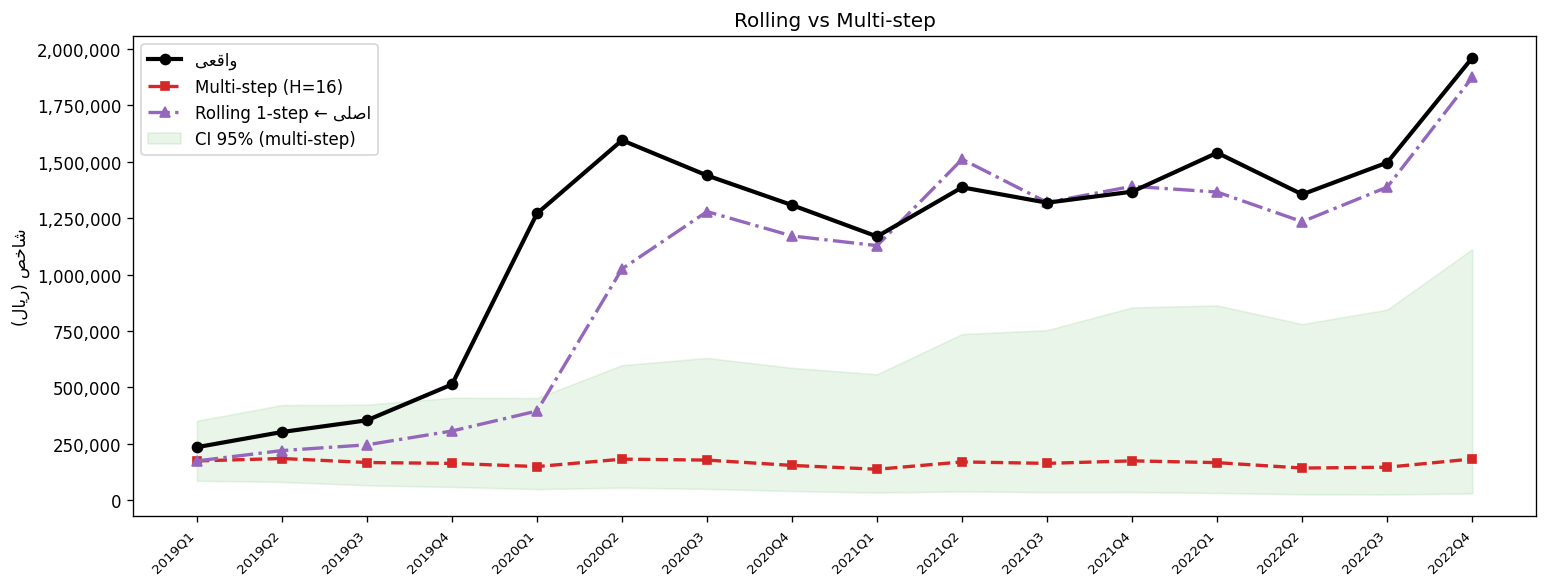

✓ نمودار ۱۰ ذخیره شد
  MAPE Rolling (اصلی) : 18.53%
  MAPE Multi-step     : 78.07%


In [15]:
print("در حال محاسبه Rolling forecast (ممکن است ~۳۰ ثانیه طول بکشد)...")
rolling_preds_log = []
y_roll = y_train.copy()
X_roll = X_train.copy()

for t in range(len(y_test)):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mod_r = SARIMAX(y_roll, exog=X_roll,
                        order=best_order, seasonal_order=(0,0,0,4),
                        enforce_stationarity=False, enforce_invertibility=False)
        res_r = mod_r.fit(disp=False, maxiter=200, method="powell")
    fc_r  = res_r.forecast(steps=1, exog=X_test.iloc[[t]])
    rolling_preds_log.append(float(fc_r.iloc[0]))
    # به‌روزرسانی با مقدار واقعی
    y_roll = pd.concat([y_roll,
                        pd.Series([y_test.iloc[t]], index=[y_test.index[t]])])
    X_roll = pd.concat([X_roll, X_test.iloc[[t]]])

rolling_preds_price = np.exp(rolling_preds_log)

# نمودار ۱۰ — Rolling vs Multi-step
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x_t, y_true_price,       color="black",   marker="o", ms=6, lw=2.5,
        label=fp("واقعی"), zorder=6)
ax.plot(x_t, y_pred_price,       color="#d62728",  marker="s", ms=5, lw=2,
        linestyle="--", label=fp("Multi-step (H=16)"), zorder=4)
ax.plot(x_t, rolling_preds_price,color="#9467bd",  marker="^", ms=6, lw=2,
        linestyle="-.", label=fp("Rolling 1-step ← اصلی"), zorder=5)
ax.fill_between(x_t, ci_lower, ci_upper, alpha=0.1, color="#2ca02c",
                label=fp("CI 95% (multi-step)"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax.set_ylabel(fp("شاخص (ریال)")); ax.set_title(fp("Rolling vs Multi-step"), fontsize=12)
ax.set_xticks(x_t)
ax.set_xticklabels(y_test.index.astype(str), rotation=45, ha="right", fontsize=8)
ax.legend(); plt.tight_layout()
plt.savefig("../results/figures/02_rolling_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

r_mape = np.mean(np.abs((y_true_price-rolling_preds_price)/y_true_price))*100
m_mape = np.mean(np.abs((y_true_price-y_pred_price)/y_true_price))*100
print(f"✓ نمودار ۱۰ ذخیره شد")
print(f"  MAPE Rolling (اصلی) : {r_mape:.2f}%")
print(f"  MAPE Multi-step     : {m_mape:.2f}%")

## ۱۴. عملکرد به تفکیک رژیم اقتصادی

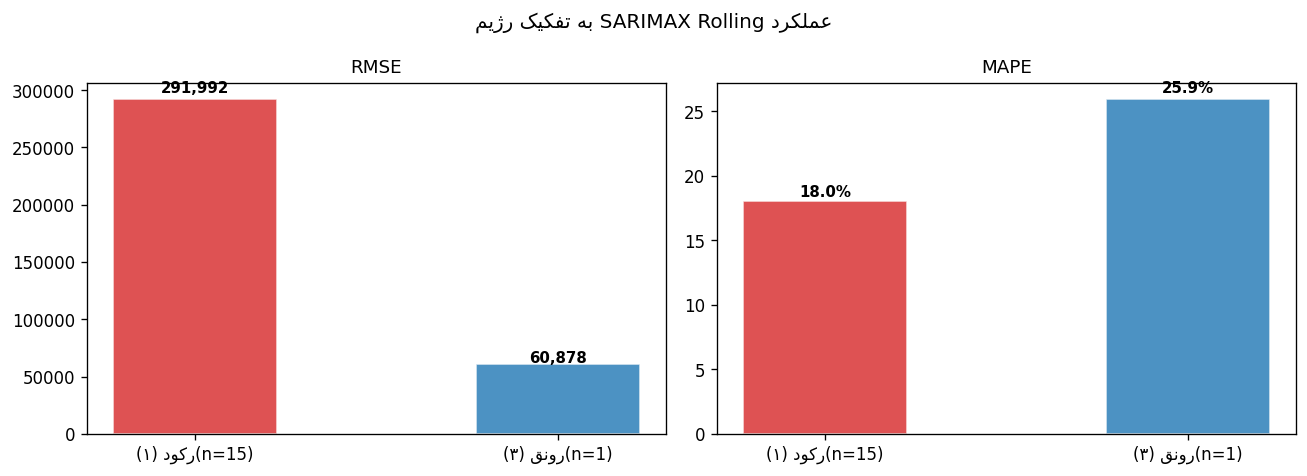

✓ نمودار ۱۱ ذخیره شد


In [16]:
# نمودار ۱۱ — عملکرد به تفکیک چرخه (بر اساس rolling)
cycle_vals   = test_c["cycle"].values
cycle_colors = {1:"#d62728", 2:"#2ca02c", 3:"#1f77b4"}
cyc_names    = {1:fp("رکود (۱)"), 2:fp("عادی (۲)"), 3:fp("رونق (۳)")}
cyc_m = {}
for c in sorted(set(cycle_vals.astype(int))):
    mask = cycle_vals == c
    if not mask.any(): continue
    yt, yp = y_true_price[mask], rolling_preds_price[mask]
    cyc_m[c] = {"RMSE": np.sqrt(mean_squared_error(yt,yp)),
                "MAPE": np.mean(np.abs((yt-yp)/yt))*100, "n": mask.sum()}

keys = sorted(cyc_m.keys())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax_i, metric in enumerate(["RMSE","MAPE"]):
    vals   = [cyc_m[k][metric] for k in keys]
    labels = [f"{cyc_names.get(k,k)}(n={cyc_m[k]['n']})" for k in keys]
    bars   = axes[ax_i].bar(labels, vals,
                             color=[cycle_colors.get(k,"gray") for k in keys],
                             alpha=0.8, edgecolor="white", width=0.45)
    for bar, v in zip(bars, vals):
        axes[ax_i].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                         f"{v:,.0f}" if metric=="RMSE" else f"{v:.1f}%",
                         ha="center", fontsize=9, fontweight="bold")
    axes[ax_i].set_title(f"{metric}", fontsize=11)
plt.suptitle(fp("عملکرد SARIMAX Rolling به تفکیک رژیم"), fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/02_performance_by_cycle.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۱۱ ذخیره شد")

## ۱۵. معیارهای ارزیابی و مقایسه با XGBoost

In [17]:
# معیارها بر اساس Rolling (واقعی‌بینانه‌تر)
RMSE = np.sqrt(mean_squared_error(y_true_price, rolling_preds_price))
MAE  = mean_absolute_error(y_true_price, rolling_preds_price)
MAPE = np.mean(np.abs((y_true_price-rolling_preds_price)/y_true_price))*100
R2   = r2_score(y_true_price, rolling_preds_price)
metrics = {"model":"SARIMAX","RMSE":RMSE,"MAE":MAE,"MAPE":MAPE,"R2":R2}

print("╔════════════════════════════════════════╗")
print(f"║  {'مدل: SARIMAX (Rolling 1-step)':^38} ║")
print("╠════════════════════════════════════════╣")
print(f"║  {'RMSE':<12} {RMSE:>23,.2f}  ║")
print(f"║  {'MAE':<12} {MAE:>23,.2f}  ║")
print(f"║  {'MAPE':<12} {MAPE:>22.2f}%  ║")
print(f"║  {'R²':<12} {R2:>24.4f}  ║")
print("╚════════════════════════════════════════╝")

╔════════════════════════════════════════╗
║      مدل: SARIMAX (Rolling 1-step)      ║
╠════════════════════════════════════════╣
║  RMSE                      283,128.98  ║
║  MAE                       180,088.34  ║
║  MAPE                          18.53%  ║
║  R²                             0.6807  ║
╚════════════════════════════════════════╝


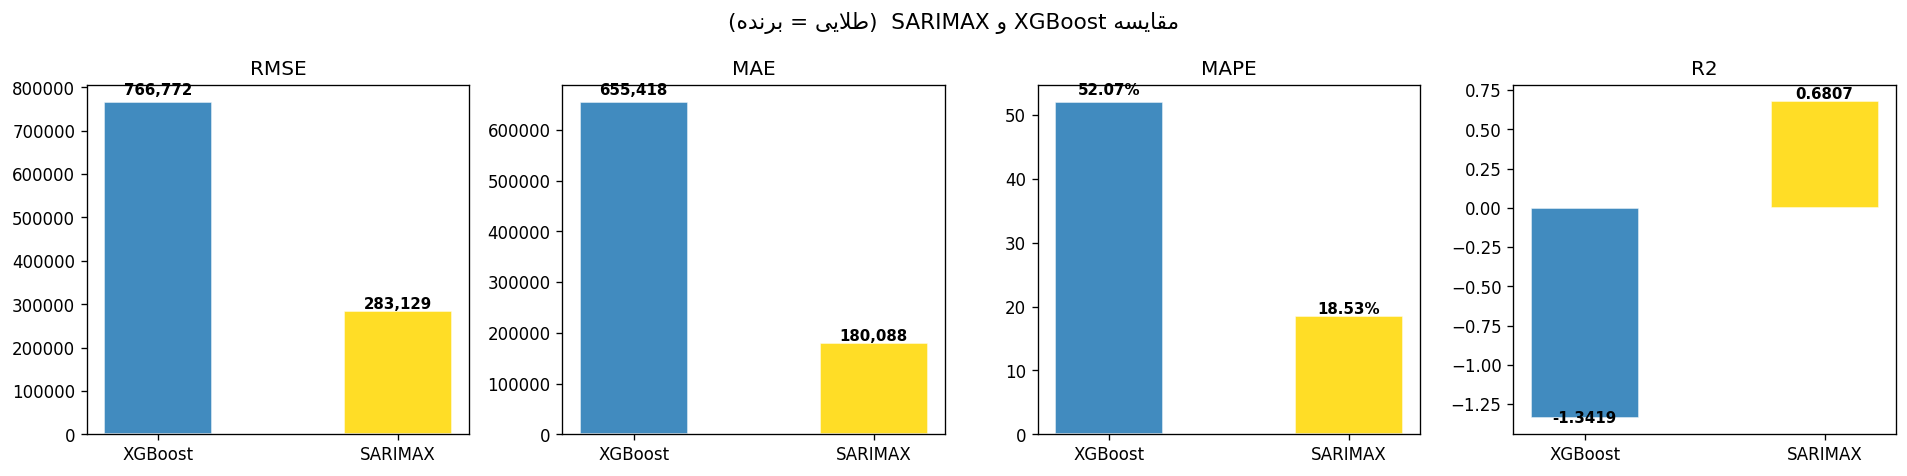

✓ نمودار ۱۲ ذخیره شد


In [18]:
# نمودار ۱۲ — مقایسه با XGBoost
xgb_path = "../results/metrics/01_xgboost_metrics.csv"
has_xgb  = os.path.exists(xgb_path)

if has_xgb:
    xgb_m   = pd.read_csv(xgb_path).iloc[0]
    m_names = ["XGBoost","SARIMAX"]
    m_cols  = ["#1f77b4","#d62728"]
    xgb_v   = [xgb_m["RMSE"],xgb_m["MAE"],xgb_m["MAPE"],xgb_m["R2"]]
    sar_v   = [RMSE,MAE,MAPE,R2]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax_i, (metric, xv, sv) in enumerate(zip(["RMSE","MAE","MAPE","R2"],xgb_v,sar_v)):
        vals   = [xv, sv]
        winner = int(np.argmin(vals)) if metric!="R2" else int(np.argmax(vals))
        bar_c  = ["#ffd700" if i==winner else c for i,c in enumerate(m_cols)]
        bars   = axes[ax_i].bar(m_names, vals, color=bar_c, alpha=0.85,
                                 edgecolor="white", width=0.45)
        for bar, v in zip(bars, vals):
            fmt = f"{v:,.0f}" if metric in ["RMSE","MAE"] else                   (f"{v:.2f}%" if metric=="MAPE" else f"{v:.4f}")
            axes[ax_i].text(bar.get_x()+bar.get_width()/2,
                             bar.get_height()*1.02, fmt,
                             ha="center", fontsize=9, fontweight="bold")
        axes[ax_i].set_title(metric, fontsize=12)
    plt.suptitle(fp("مقایسه XGBoost و SARIMAX  (طلایی = برنده)"), fontsize=13)
    plt.tight_layout()
    plt.savefig("../results/figures/02_xgb_vs_sarimax.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ نمودار ۱۲ ذخیره شد")
else:
    print("⚠ ابتدا notebook 01 را اجرا کنید")

## ۱۶. ذخیره مدل و نتایج

In [19]:
os.makedirs("../models",          exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)

joblib.dump(fitted, "../models/02_sarimax_model.pkl")

pd.DataFrame([metrics]).to_csv("../results/metrics/02_sarimax_metrics.csv", index=False)

pred_df = pd.DataFrame({
    "period":    y_test.index.astype(str),
    "actual":    y_true_price.astype(int),
    "predicted": rolling_preds_price.astype(int),
    "lower_95":  ci_lower.astype(int),
    "upper_95":  ci_upper.astype(int),
    "multistep": y_pred_price.astype(int),
    "error_pct": np.round((rolling_preds_price-y_true_price)/y_true_price*100, 2),
    "cycle":     test_c["cycle"].values.astype(int)
})
pred_df.to_csv("../results/metrics/02_sarimax_predictions.csv", index=False)

print("✓ مدل    : ../models/02_sarimax_model.pkl")
print("✓ معیارها: ../results/metrics/02_sarimax_metrics.csv")
figs = sorted([f for f in os.listdir("../results/figures") if f.startswith("02_")])
for f in figs: print(f"  📊 {f}")

✓ مدل    : ../models/02_sarimax_model.pkl
✓ معیارها: ../results/metrics/02_sarimax_metrics.csv
  📊 02_acf_pacf.png
  📊 02_aic_bic_heatmap.png
  📊 02_coefficients.png
  📊 02_forecast_with_ci.png
  📊 02_insample_fit.png
  📊 02_performance_by_cycle.png
  📊 02_residual_diagnostics.png
  📊 02_rolling_forecast.png
  📊 02_stationarity_tests.png
  📊 02_stl_decomposition.png
  📊 02_vif_analysis.png
  📊 02_xgb_vs_sarimax.png


## ✅ خلاصه نتایج مدل SARIMAX

| # | نمودار | نوع |
|---|--------|-----|
| ۱ | `02_stl_decomposition` | Multi-panel Line |
| ۲ | `02_stationarity_tests` | جدول رنگی |
| ۳ | `02_acf_pacf` | Correlogram 2×2 |
| ۴ | `02_vif_analysis` | Horizontal Bar |
| ۵ | `02_aic_bic_heatmap` | Heatmap |
| ۶ | `02_coefficients` | Bar + t-stat |
| ۷ | `02_residual_diagnostics` | 4-Panel |
| ۸ | `02_insample_fit` | Line |
| ۹ | `02_forecast_with_ci` | Line + CI Band |
| ۱۰ | `02_rolling_forecast` | Multi-line |
| ۱۱ | `02_performance_by_cycle` | Grouped Bar |
| ۱۲ | `02_xgb_vs_sarimax` | Grouped Bar |

**مرحله بعدی:** `03_gru.ipynb`